# Experiments notebook

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.ML.config import FULL_FEATURES, RANDOM_STATE, TEST_SIZE, CV_FOLDS,EXCLUDED,TARGET
from src.ML.pipelines import create_LR_pipeline, create_RF_pipeline, create_SVR_pipeline,create_XGBOOST_pipeline
from src.ML.evaluation import *
from src.ML.visualization import *
from src.ML.io_utils import *
from src.ML.tunning import tune_RF, tune_SVR,tune_XGBOOST
from sklearn.decomposition import PCA

csv_address= os.path.abspath(os.path.join(os.getcwd(), "..", "Features", "all_subjects_features.csv"))

## Load data/Generate random data

In [2]:
from sklearn.model_selection import train_test_split

"""
def make_random_data(n_samples=200):
    X=pd.DataFrame(
        np.random.randn(n_samples,len(FULL_FEATURES)),
                        columns=FULL_FEATURES
    )
    y=np.random.uniform(0,10,n_samples)
    return X,y

x,y=make_random_data()
"""
x,y=load_data(csv_path=csv_address,target_name=TARGET,exclude_cols=EXCLUDED)
FULL_FEATURES=x.columns
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

Original shape: (14877, 109)
Number of rows with at least one NaN: 313
New shape: (5594, 109)


## Correlation with target!

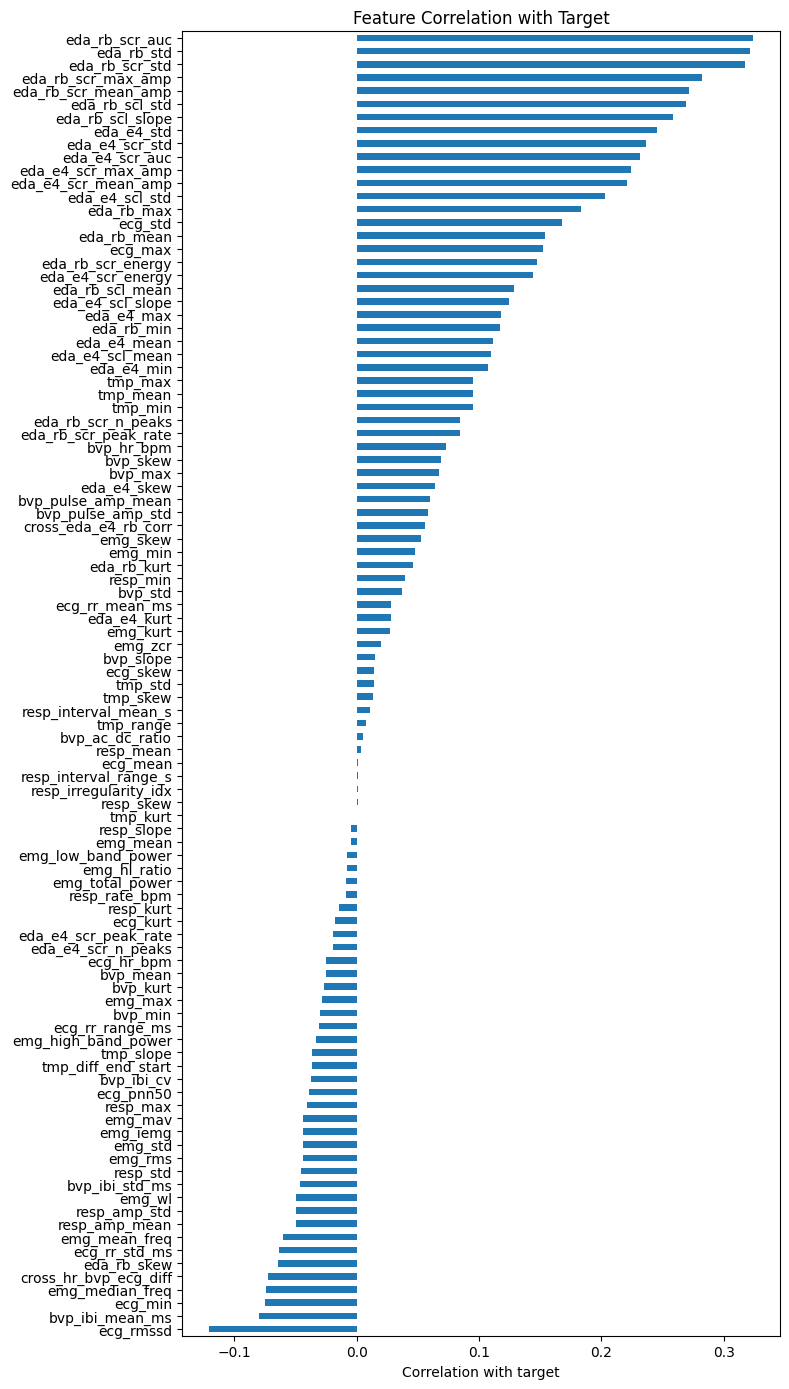

In [3]:
plot_corr_with_target(x, y)

In [4]:
import pandas as pd
import numpy as np

def filter_features_by_target_corr(X, y, threshold=0.05, return_info=False):
    """
    Remove columns from X whose absolute Pearson correlation with y is < threshold
    or whose correlation is NaN.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series, pd.DataFrame, np.ndarray, or list
        Target vector.
    threshold : float, default=0.05
        Minimum absolute correlation required to keep a feature.
    return_info : bool, default=False
        If True, also returns a DataFrame with correlations and keep/remove status.

    Returns
    -------
    X_filtered : pd.DataFrame
        Filtered feature matrix.
    info : pd.DataFrame, optional
        Summary table with feature, correlation, abs_correlation, and kept status.
        Only returned if return_info=True.
    """
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a pandas DataFrame.")

    # Convert y to Series
    if isinstance(y, pd.DataFrame):
        if y.shape[1] != 1:
            raise ValueError("If y is a DataFrame, it must have exactly one column.")
        y = y.iloc[:, 0]
    elif not isinstance(y, pd.Series):
        y = pd.Series(y, name="target")

    # Align indices if possible
    if len(X) != len(y):
        raise ValueError("X and y must have the same number of rows.")

    # Compute correlations column by column
    corrs = X.apply(lambda col: col.corr(y))

    # Keep only non-NaN correlations with abs(corr) >= threshold
    keep_mask = corrs.notna() & (corrs.abs() >= threshold)
    print( (corrs.abs() < threshold))
    kept_columns = corrs.index[keep_mask].tolist()

    X_filtered = X[kept_columns].copy()
    print(X_filtered.size)
    if return_info:
        info = pd.DataFrame({
            "feature": corrs.index,
            "correlation": corrs.values,
            "abs_correlation": corrs.abs().values,
            "kept": keep_mask.values
        }).sort_values("abs_correlation", ascending=False).reset_index(drop=True)

        return X_filtered, info

    return X_filtered


In [5]:
X_filtered = filter_features_by_target_corr(x, y, threshold=0.05, return_info=False)
FULL_FEATURES=X_filtered.columns
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

ecg_mean                  True
ecg_std                  False
ecg_min                  False
ecg_max                  False
ecg_skew                  True
                         ...  
resp_amp_mean             True
resp_amp_std              True
resp_dominant_freq       False
cross_eda_e4_rb_corr     False
cross_hr_bvp_ecg_diff    False
Length: 78, dtype: bool
86210


C:\Users\34648\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\34648\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## PCA?


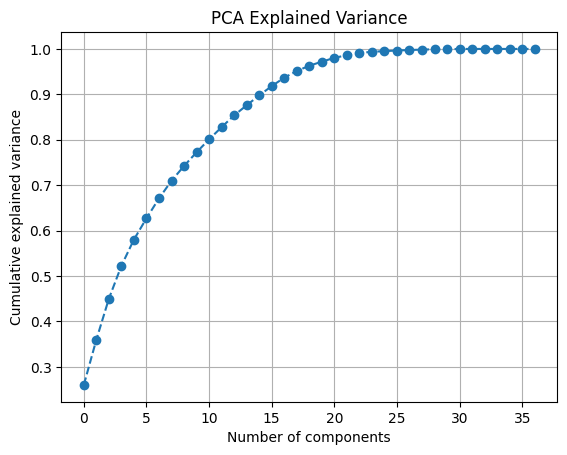

In [6]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca = PCA()
pca.fit(X_train_scaled)

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    linestyle='--',   
    marker='o'        #
)

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.grid(True)

plt.show()

## Run model (baseline)


In [6]:
pipeline_lr=create_LR_pipeline()
pipeline_rf=create_RF_pipeline()
pipeline_svr=create_SVR_pipeline()
pipeline_xgboost=create_XGBOOST_pipeline()

metrics_lr,y_pred_lr=train_and_evaluate(pipeline_lr, X_train, y_train, X_test, y_test)
metrics_rf,y_pred_rf=train_and_evaluate(pipeline_rf, X_train, y_train, X_test, y_test)
metrics_svr,y_pred_svr=train_and_evaluate(pipeline_svr, X_train, y_train, X_test, y_test)
metrics_xgboost,y_pred_xgboost=train_and_evaluate(pipeline_xgboost,X_train,y_train,X_test,y_test)

print("LR Metrics:", metrics_lr)
print("RF Metrics:", metrics_rf)
print("SVR Metrics:", metrics_svr)
print("XGBOOST:",metrics_xgboost)

LR Metrics: {'MSE': 1017.6900793955817, 'R2': 0.06653156097324875, 'RMSE': np.float64(31.9012551382478), 'MAE': 25.341481206215864}
RF Metrics: {'MSE': 685.507450660229, 'R2': 0.3712235356671103, 'RMSE': np.float64(26.18219720841299), 'MAE': 21.439849070100145}
SVR Metrics: {'MSE': 931.5417062754442, 'R2': 0.14555049710055135, 'RMSE': np.float64(30.521168166953313), 'MAE': 25.36110879547901}
XGBOOST: {'MSE': 704.0290758166176, 'R2': 0.35423471670049433, 'RMSE': np.float64(26.533546235221134), 'MAE': 21.35587748612713}


In [8]:
results = []
results.append({"Model": "Linear Regression", **metrics_lr})
results.append({"Model": "Random Forest", **metrics_rf})
results.append({"Model": "SVR", **metrics_svr})

results_df = pd.DataFrame(results)
results_df

,Model,MSE,R2,RMSE,MAE
0,Linear Regression,1017.690079,0.066532,31.901255,25.341481
1,Random Forest,685.507451,0.371224,26.182197,21.439849
2,SVR,931.541706,0.145550,30.521168,25.361109


## PLOTS

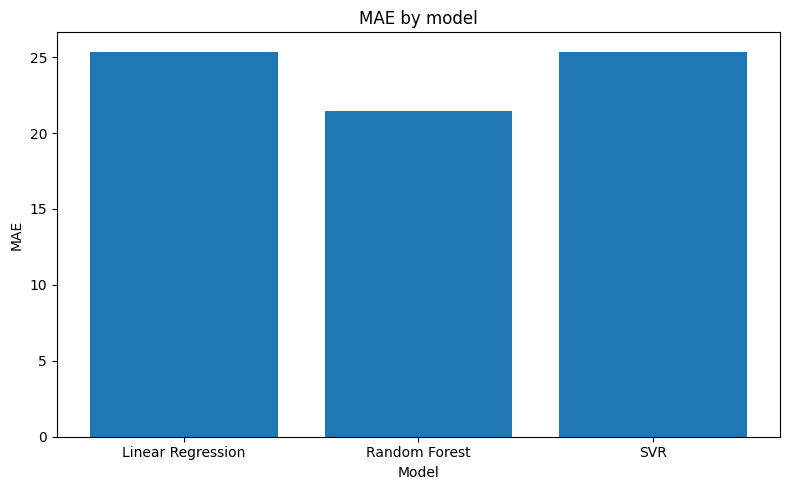

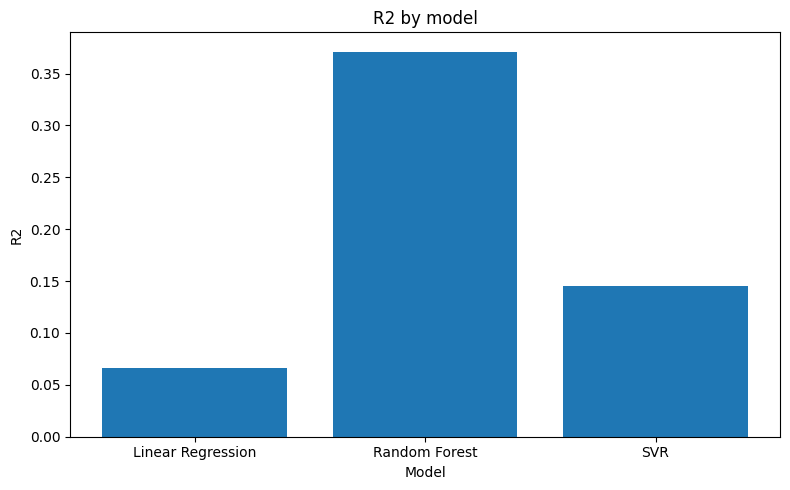

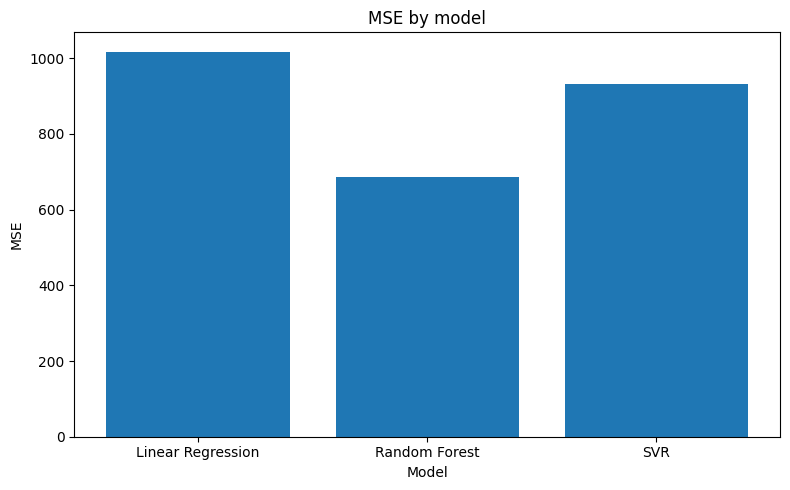

In [9]:
plot_metric_by_model(results_df, metric="MAE")
plot_metric_by_model(results_df, metric="R2")
plot_metric_by_model(results_df, metric="MSE")

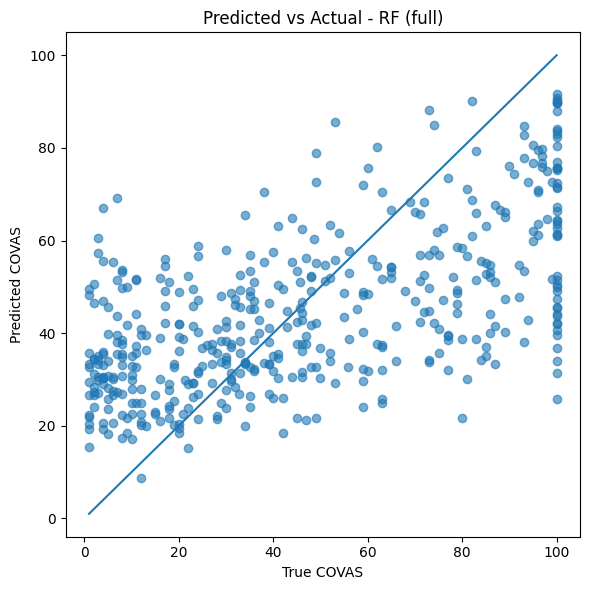

In [10]:
plot_predicted_vs_actual(y_test, y_pred_rf, model_name="RF", feature_set="full")

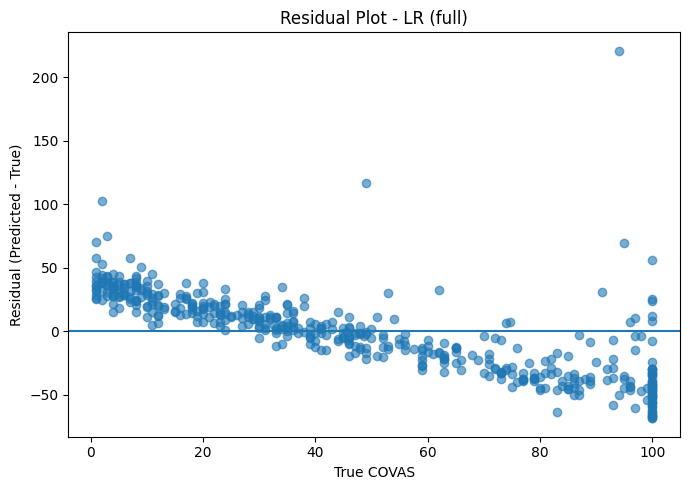

In [11]:
plot_residuals(y_test, y_pred_lr, model_name="LR", feature_set="full")

### LINEAR REGRESSION ASSUMPTIONS

1. Residues follow a **normal distribution**
2. Residues have **zero mean** and **constant variance**
3. Residues are **independent** (aka no real structure)
4. **Linearity**  (check resiudals vs fitted values)

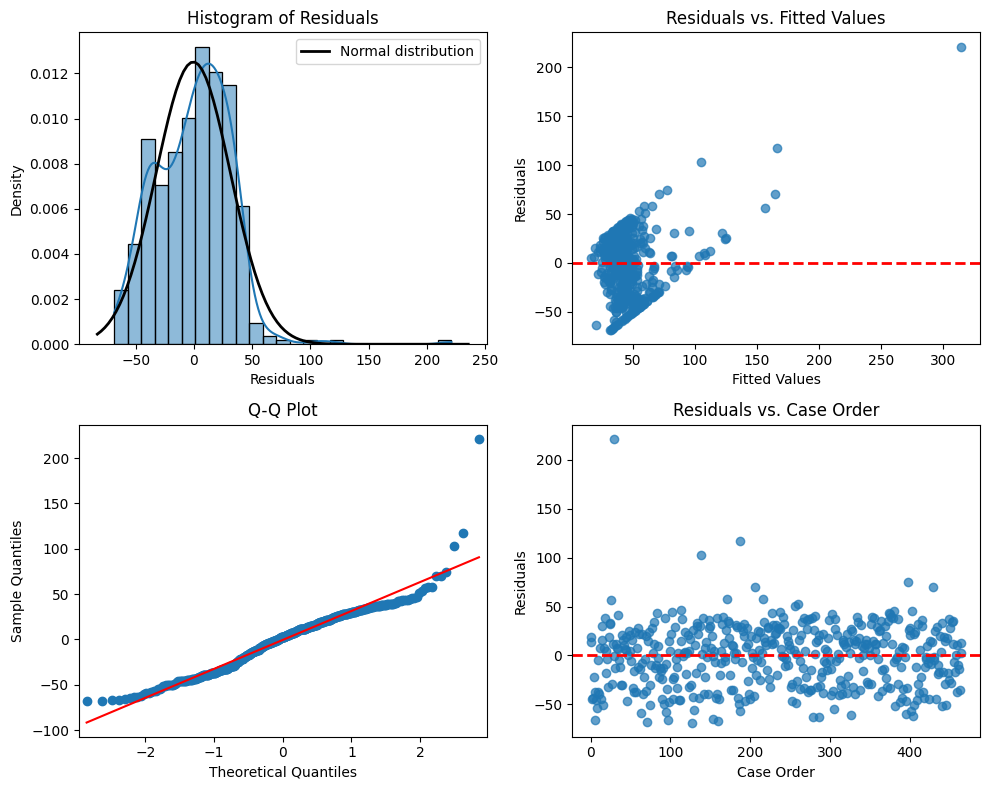

In [12]:
residual_analysis(y_test, y_pred_lr)

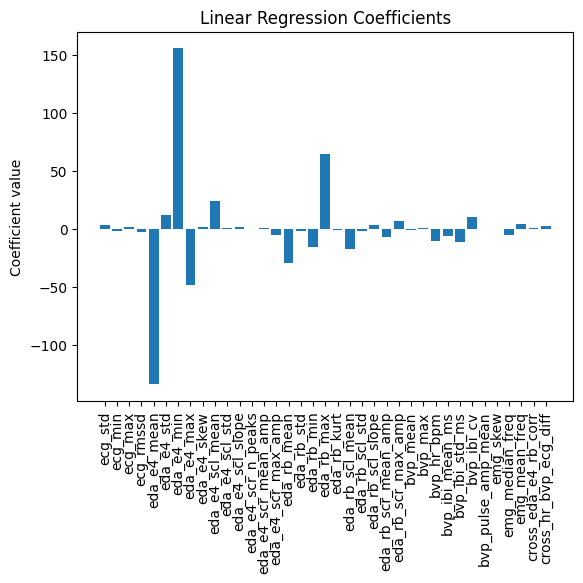

In [13]:
plot_lr_coefficients(pipeline_lr, feature_names=FULL_FEATURES)

### SVR tunnnig


In [14]:
grid_svr = tune_SVR(X_train, y_train)
print(grid_svr.best_params_)
best_svr = grid_svr.best_estimator_
print(grid_svr.best_score_)

{'model__C': 100, 'model__epsilon': 0.5, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
0.23689773159232044


In [15]:
metrics_best_svr,y_pred_best_svr=train_and_evaluate(best_svr, X_train, y_train, X_test, y_test)
print("Tuned SVR Metrics:", metrics_best_svr)

Tuned SVR Metrics: {'MSE': 706.1410651370447, 'R2': 0.3522975106550632, 'RMSE': np.float64(26.57331490682043), 'MAE': 20.99677714079062}


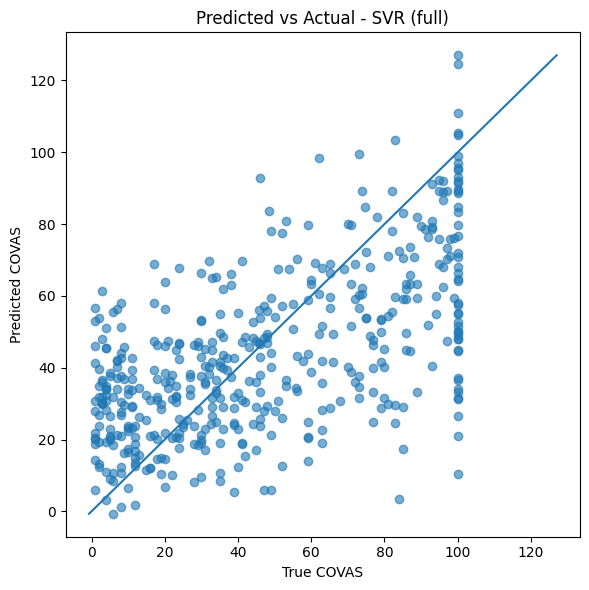

In [16]:
plot_predicted_vs_actual(y_test, y_pred_best_svr, model_name="SVR", feature_set="full")

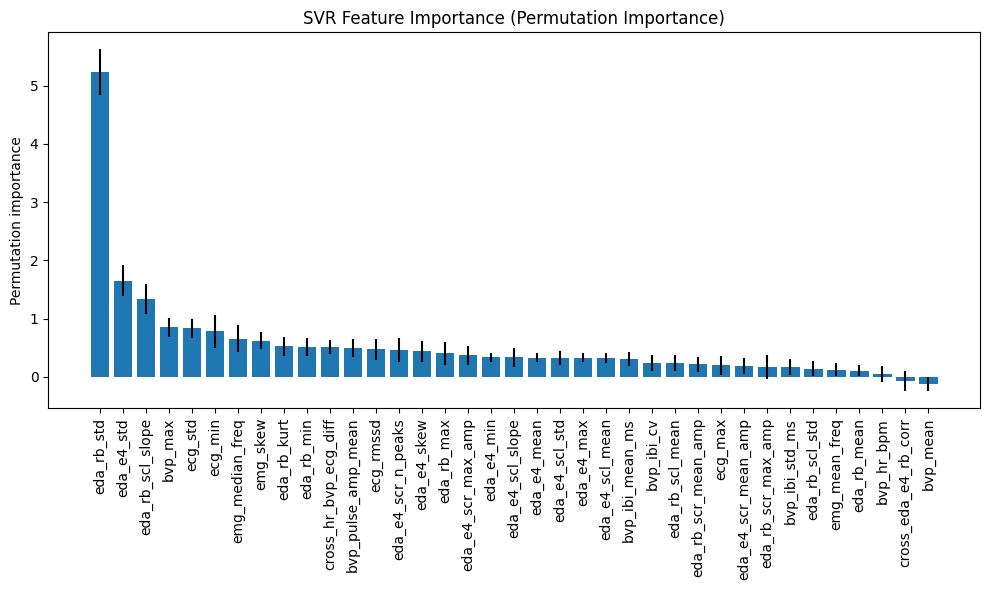

In [17]:

plot_svr_permutation_importance(
    best_svr,
    X_test,
    y_test,
    FULL_FEATURES
)


In [18]:
"""
importance_df = compute_permutation_importance_df(
    pipeline=best_svr,
    X=X_train,
    y=y_train,
    feature_names=X_train.columns,
    n_repeats=10
)

top_15_features = get_top_features_from_importance(
    importance_df,
    n_top=15,
    only_positive=True   
)

print("Top 15 features:")
print(top_15_features)

importance_df.head(15)
"""

'\nimportance_df = compute_permutation_importance_df(\n    pipeline=best_svr,\n    X=X_train,\n    y=y_train,\n    feature_names=X_train.columns,\n    n_repeats=10\n)\n\ntop_15_features = get_top_features_from_importance(\n    importance_df,\n    n_top=15,\n    only_positive=True   \n)\n\nprint("Top 15 features:")\nprint(top_15_features)\n\nimportance_df.head(15)\n'

In [19]:
#X_train_top15 = X_train[top_15_features].copy()
#X_test_top15  = X_test[top_15_features].copy()

In [20]:
"""
grid_svr_top15 = tune_SVR(X_train_top15, y_train, PCA_n_components=None)
print(grid_svr_top15.best_params_)
print(grid_svr_top15.best_score_)

best_svr_top15 = grid_svr_top15.best_estimator_
"""

'\ngrid_svr_top15 = tune_SVR(X_train_top15, y_train, PCA_n_components=None)\nprint(grid_svr_top15.best_params_)\nprint(grid_svr_top15.best_score_)\n\nbest_svr_top15 = grid_svr_top15.best_estimator_\n'

### Random Forest tunning

In [21]:
grid_rf = tune_RF(X_train, y_train)

print(grid_rf.best_params_)
best_rf = grid_rf.best_estimator_
print(grid_rf.best_score_)

{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
0.30835297085632357


In [22]:
metrics_best_rf,y_pred_best_rf=train_and_evaluate(best_rf, X_train, y_train, X_test, y_test)
print("Tuned RF Metrics:", metrics_best_rf)

Tuned RF Metrics: {'MSE': 667.9648989994055, 'R2': 0.3873143069607645, 'RMSE': np.float64(25.845016908475905), 'MAE': 21.39265291278587}


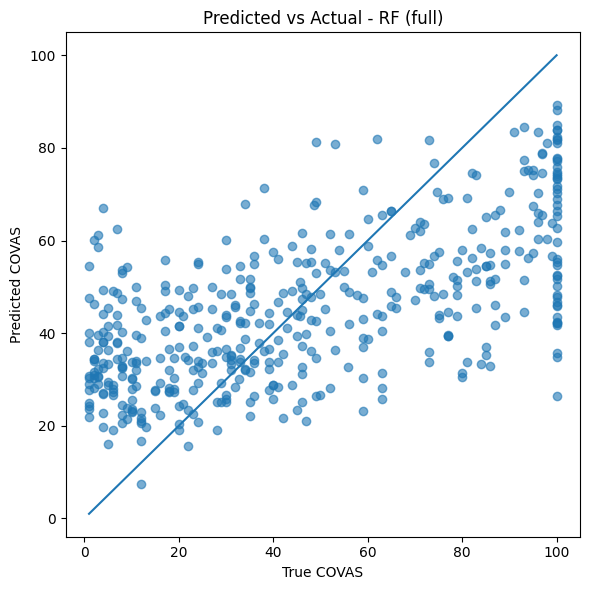

In [23]:
plot_predicted_vs_actual(y_test, y_pred_best_rf, model_name="RF", feature_set="full")

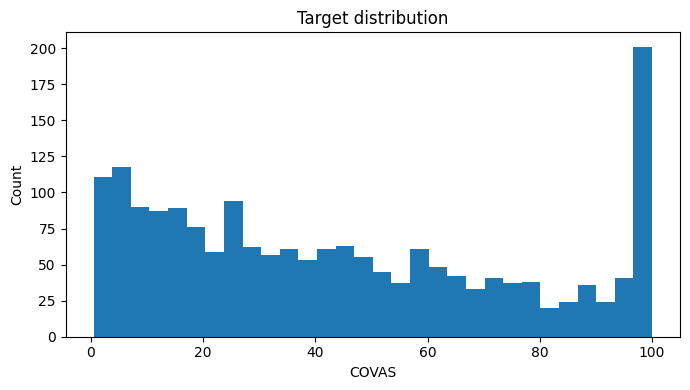

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(y_train, bins=30)
plt.xlabel("COVAS")
plt.ylabel("Count")
plt.title("Target distribution")
plt.tight_layout()
plt.show()

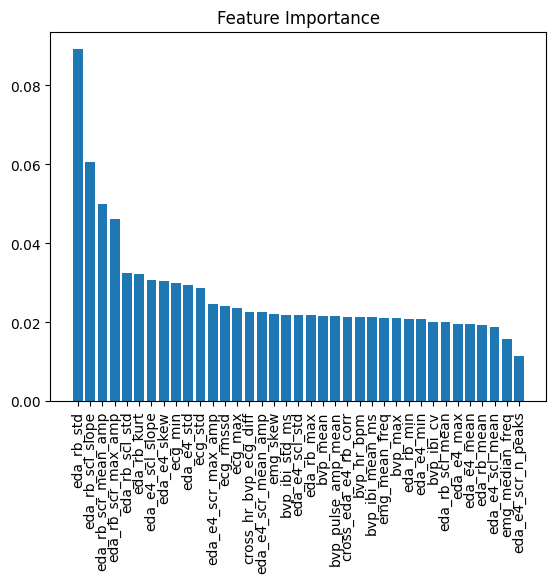

In [25]:
plot_feature_importance_rf(best_rf, feature_names=FULL_FEATURES)

## XGBOOST

In [6]:
grid_xgboost = tune_XGBOOST(X_train, y_train)

print(grid_xgboost.best_params_)
best_xgboost = grid_xgboost.best_estimator_
print(grid_xgboost.best_score_)

{'model__colsample_bytree': 0.9, 'model__learning_rate': 0.03, 'model__max_depth': 6, 'model__min_child_weight': 1, 'model__n_estimators': 400, 'model__reg_lambda': 7.0, 'model__subsample': 0.9}
0.3211249163973005
